## Module 1: Data Preparation and Backend Setup

### Task 1: E-commerce Dataset Cleaning

- *Objective*: Ensure the dataset is clean and ready for analysis and vectorization.
- *Key Actions*: Remove duplicates, handle missing values, and standardize formats.

In [1]:
# Import necessary modules
import pandas as pd
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

from src.utils.data_cleaning import clean_dataset

# Load dataset and drop duplicate rows
df = pd.read_csv('..\src\data\dataset\dataset.csv')
df = df.drop_duplicates()

df.head(1)

<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
C:\Users\don\AppData\Local\Temp\ipykernel_17524\772045875.py:12: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv('..\src\data\dataset\dataset.csv')


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,XxYUnited Kingdom☺️


In [4]:
df_cleaned = clean_dataset(df)
df_cleaned = df_cleaned.drop_duplicates(subset='StockCode', keep='last')
df_cleaned.to_csv('../src/data/dataset/cleaned_ecommerce_data.csv')

c:\Users\don\dev\ds-test\ds_task_1ab\src\utils\data_cleaning.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Quantity'] = df['Quantity'].fillna(1)
c:\Users\don\dev\ds-test\ds_task_1ab\src\utils\data_cleaning.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['InvoiceDate'] = df['InvoiceDate'].fillna('1970-01-01 00:00:00')
c:\Users\don\dev\ds-test\ds_task_1ab\src\utils\data_cleaning.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc

### Task 2: Vector Database Creation

- *Objective*: Set up a vector database using Pinecone to store product vectors.
- *Key Actions*: Define the database schema and integrate with Pinecone.

In [3]:
# point to util

In [4]:
# # First encode the query text into a vector
# query_vector = model.encode("Tell me about decorative items for home.")

# # Then query Pinecone with the vector
# results = index.query(
#     vector=query_vector.tolist(),
#     top_k=3,
#     include_metadata=True
# )

# # Print the results
# for match in results.matches:
#     print(f"Product: {match.metadata['Description']}")
#     print(f"Price: ${match.metadata['UnitPrice']}")
#     print(f"Score: {match.score}")
#     print("---")

### Task 3: Similarity Metrics Selection

- *Objective*: Choose and justify the similarity metrics used to compare product vectors.
- *Key Actions*: Evaluate different metrics (e.g., cosine similarity, dot product) and select the best fit based on the dataset characteristics.


In [5]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from scipy.spatial.distance import cosine
import matplotlib.pyplot as plt
import seaborn as sns
from pinecone import Pinecone, ServerlessSpec
from sentence_transformers import SentenceTransformer
from dotenv import load_dotenv
import os
import time

load_dotenv()
api_key = os.getenv('PINECONE_API_KEY')

model = SentenceTransformer('all-MiniLM-L6-v2')
pc = Pinecone(api_key=api_key)
index = pc.Index("product-vectors")

c:\Users\don\dev\ds-test\ds_task_1ab\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


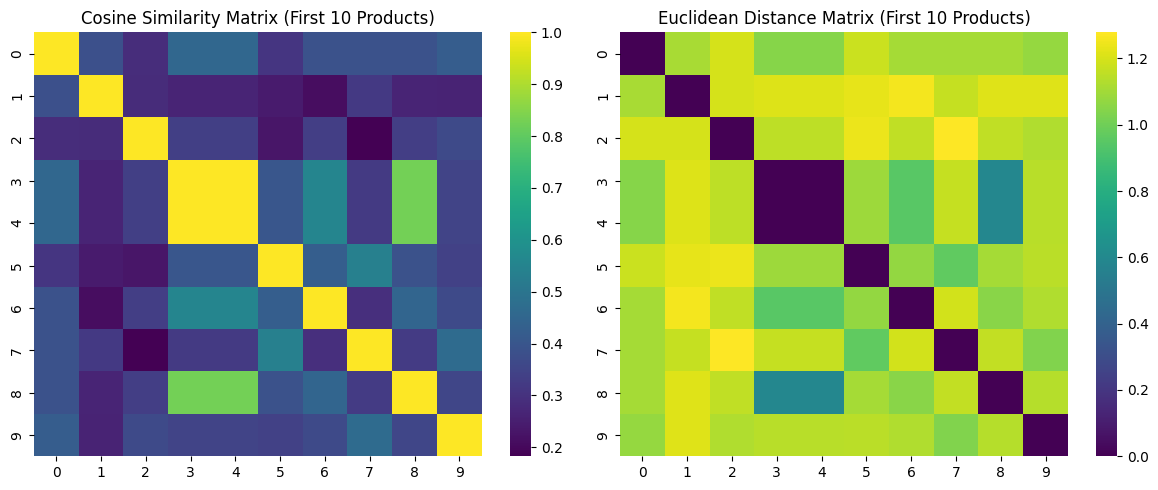

In [6]:
# Get a sample of product embeddings
query_vector = model.encode("product")  # Use a meaningful query
results = index.query(
    vector=query_vector.tolist(),
    top_k=1000,
    include_metadata=True,
    include_values=True
)

# Extract embeddings and metadata
embeddings = np.array([match.values for match in results.matches])  
descriptions = [match.metadata['Description'] for match in results.matches]

# Calculate different similarity metrics
# 1. Cosine Similarity
cosine_sim = cosine_similarity(embeddings)

# 2. Euclidean Distance
euclidean_dist = euclidean_distances(embeddings)

# Visualize the results
plt.figure(figsize=(12, 5))

# Plot Cosine Similarity
plt.subplot(1, 2, 1)
sns.heatmap(cosine_sim[:10, :10], cmap='viridis')
plt.title('Cosine Similarity Matrix (First 10 Products)')

# Plot Euclidean Distance
plt.subplot(1, 2, 2)
sns.heatmap(euclidean_dist[:10, :10], cmap='viridis')
plt.title('Euclidean Distance Matrix (First 10 Products)')

plt.tight_layout()
plt.show()

In [7]:
# Print some example comparisons
print("\nExample Product Similarities:")
for i in range(3):
    print(f"\nProduct: {descriptions[i]}")
    # Get top 3 most similar products
    similar_indices = cosine_sim[i].argsort()[-4:-1][::-1]
    for idx in similar_indices:
        print(f"Similar to: {descriptions[idx]} (Score: {cosine_sim[i][idx]:.3f})")


Example Product Similarities:

Product: ASS DES PHONE SPONGE CRAFT STICKER
Similar to: FOOD/DRINK SPONGE STICKERS (Score: 0.639)
Similar to: ASSTD DESIGN 3D PAPER STICKERS (Score: 0.601)
Similar to: CANDY SHOP  STICKER SHEET (Score: 0.600)

Product: HELLO SAILOR BLUE SOAP HOLDER
Similar to: FAIRY SOAP SOAP HOLDER (Score: 0.571)
Similar to: STARFISH SOAP DISH (Score: 0.431)
Similar to: SOAP DISH BROCANTE (Score: 0.430)

Product: DOCTOR'S BAG SOFT TOY
Similar to: NURSE'S BAG SOFT TOY (Score: 0.772)
Similar to: JUMBO BAG TOYS (Score: 0.613)
Similar to: TOOL BOX SOFT TOY (Score: 0.609)
